
# Working with XES Event Logs in Python

**This notebook is part of the Process Intelligence in Action (2AMI30) course**

This notebook is a hands-on introduction to the **XES (.xes) event log format**, which is widely used in **process mining**.  
You are expected to be comfortable with Python, pandas, and Jupyter notebooks.

This notebook will cover:
- Understanding the structure of an XES file (log → trace → event)
- Loading and inspecting XES files in Python
- Converting XES logs to pandas DataFrames
- Performing basic exploratory analysis on event logs

We will use the `pm4py` library, the de‑facto standard for process mining in Python.



## 1. Understanding the structure of an XES file

The **eXtensible Event Stream (XES)** format is an XML-based standard for event logs.

Conceptually, an XES log has three nested levels:

1. **Log** – the whole dataset
2. **Trace** – one process instance
3. **Event** – one step in the process

Each level can have **attributes**:
- Events typically have: `concept:name`, `time:timestamp`, `org:resource`
- Traces often have: `case_id`, `customer`, `variant`

Think of a trace as a sequence of time-ordered events describing *what happened* for a single case.



## 2. Required libraries

We use **pm4py** for reading and analyzing XES logs.

If pm4py is not installed, run the following (once):
```bash
pip install pm4py
```


In [1]:

import pm4py
import pandas as pd

from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.conversion.log import converter as log_converter


C:\Users\Sujitha\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



## 3. Loading an XES file

Place your `.xes` file in the same directory as this notebook, or update the path below.


In [2]:

# Update this path to your XES file
xes_path = "Supermarket_Customer.xes"

log = xes_importer.apply(xes_path)

print(type(log))
print(f"Number of traces: {len(log)}")


parsing log, completed traces ::   0%|          | 0/9557 [00:00<?, ?it/s]

<class 'pm4py.objects.log.obj.EventLog'>
Number of traces: 9557



## 4. Inspecting traces and events

An imported XES log behaves like a **list of traces**.
Each trace behaves like a **list of events**.


In [3]:

# Inspect the first trace
first_trace = log[0]

print(type(first_trace))
print(f"Number of events in first trace: {len(first_trace)}")
print("Trace attributes:")
print(first_trace.attributes)


<class 'pm4py.objects.log.obj.Trace'>
Number of events in first trace: 375
Trace attributes:
{'concept:name': '0'}


In [4]:
log[0]

{'attributes': {'concept:name': '0'}, 'events': [{'s': 'lItem', 'concept:name': 'Enter store', 'cnt': 0.0, 'x': 28.0, 'y': 0.0, 'lifecycle:transition': 'complete', 'items': 58.0, 'time:timestamp': datetime.datetime(2026, 1, 26, 14, 0, tzinfo=datetime.timezone.utc), 'p': nan, 'col': nan, 'iMI': nan, 'i': nan, 'q': nan, 'pc': nan, 'mC': nan, 'mI': nan, 'iMC': nan, 'cid': nan, 'b': nan, 'clid': nan}, '..', {'s': 'lCust', 'concept:name': 'Complete Payment', 'cnt': nan, 'x': nan, 'y': nan, 'lifecycle:transition': 'complete', 'items': nan, 'time:timestamp': datetime.datetime(2026, 2, 20, 14, 7, 28, 254000, tzinfo=datetime.timezone.utc), 'p': 'Pin', 'col': '[(0,4,118,true),(1,0,0,false),(2,0,0,false),(3,0,0,false),(4,0,0,false),(5,0,0,false),(6,0,0,false),(7,0,0,false),(8,0,0,false),(9,0,0,false),(10,0,0,false),(11,0,0,false),(12,0,0,false),(13,0,0,false),(14,0,0,false),(15,0,0,false),(16,0,0,false),(17,0,0,false)]', 'iMI': 0.0, 'i': 118.0, 'q': '[2,1,4]', 'pc': nan, 'mC': 4.0, 'mI': 118.0, '

In [5]:

# Inspect the first event of the first trace
first_event = first_trace[0]

print(type(first_event))
print(first_event)


<class 'pm4py.objects.log.obj.Event'>
{'s': 'lItem', 'concept:name': 'Enter store', 'cnt': 0.0, 'x': 28.0, 'y': 0.0, 'lifecycle:transition': 'complete', 'items': 58.0, 'time:timestamp': datetime.datetime(2026, 1, 26, 14, 0, tzinfo=datetime.timezone.utc), 'p': nan, 'col': nan, 'iMI': nan, 'i': nan, 'q': nan, 'pc': nan, 'mC': nan, 'mI': nan, 'iMC': nan, 'cid': nan, 'b': nan, 'clid': nan}



## 5. Common event attributes

Typical event attributes you should always look for:
- `concept:name` – the activity name
- `time:timestamp` – when the event occurred
- `org:resource` – who executed it (if available)

Not all logs contain all attributes.


In [6]:

# Collect all event attribute keys in the log
attribute_keys = set()

for trace in log:
    for event in trace:
        attribute_keys.update(event.keys())

attribute_keys


{'b',
 'cid',
 'clid',
 'cnt',
 'col',
 'concept:name',
 'i',
 'iMC',
 'iMI',
 'items',
 'lifecycle:transition',
 'mC',
 'mI',
 'p',
 'pc',
 'q',
 's',
 'time:timestamp',
 'x',
 'y'}


## 6. Converting an XES log to a pandas DataFrame

For data science workflows, it is often convenient to work with a **tabular representation**.

pm4py provides a built-in conversion.


In [7]:

log_df = log_converter.apply(log, variant=log_converter.Variants.TO_DATA_FRAME)

log_df.head()


,s,concept:name,cnt,x,y,lifecycle:transition,items,time:timestamp,p,col,...,i,q,pc,mC,mI,iMC,cid,b,clid,case:concept:name
0,lItem,Enter store,0.0,28.0,0.0,complete,58.0,2026-01-26 14:00:00+00:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,lItem,Pickup Item,NaN,0.0,NaN,complete,58.0,2026-01-26 14:00:00+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,lItem,Pickup Item,NaN,1.0,NaN,complete,58.0,2026-01-26 14:00:03.547000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,lItem,Pickup Item,NaN,2.0,NaN,complete,58.0,2026-01-26 14:00:06.578000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,lItem,Pickup Item,NaN,3.0,NaN,complete,58.0,2026-01-26 14:00:09.296000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0



### Interpreting the DataFrame

Typical columns:
- `case:concept:name` → case ID
- `concept:name` → activity
- `time:timestamp` → event time

Each row corresponds to **one event**.
Multiple rows with the same case ID form a trace.



## 7. Basic exploratory analysis


In [8]:

# Number of events
len(log_df)


2441070

In [9]:

# Number of unique cases
log_df['case:concept:name'].nunique()


9557

In [10]:

# Most frequent activities
log_df['concept:name'].value_counts().head(10)


concept:name
Pickup Item               1155096
Scan Item                 1127675
Enter store                 25955
Go to Checkout              25955
Enter Queue                 25325
Start Payment               25325
Complete Payment            25325
Start Price Check           14892
End price check             14892
Abandon cart and leave        630
Name: count, dtype: int64

In [11]:

# Trace length distribution
trace_lengths = log_df.groupby('case:concept:name').size()
trace_lengths.describe()


count    9557.000000
mean      255.422204
std       100.558157
min         7.000000
25%       174.000000
50%       264.000000
75%       329.000000
max       487.000000
dtype: float64


## 8. Event ordering and timestamps

Event order **must always be derived from timestamps**, not row order.


In [12]:

# Ensure correct ordering
log_df_sorted = log_df.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_sorted.head()


,s,concept:name,cnt,x,y,lifecycle:transition,items,time:timestamp,p,col,...,i,q,pc,mC,mI,iMC,cid,b,clid,case:concept:name
0,lItem,Enter store,0.0,28.0,0.0,complete,58.0,2026-01-26 14:00:00+00:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,lItem,Pickup Item,NaN,0.0,NaN,complete,58.0,2026-01-26 14:00:00+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,lItem,Pickup Item,NaN,1.0,NaN,complete,58.0,2026-01-26 14:00:03.547000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,lItem,Pickup Item,NaN,2.0,NaN,complete,58.0,2026-01-26 14:00:06.578000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,lItem,Pickup Item,NaN,3.0,NaN,complete,58.0,2026-01-26 14:00:09.296000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


## 9. Computing case duration

Case duration is the time between the first and last event of a case (trace).
This is one of the most basic but informative performance indicators.

In [13]:
# Compute case start and end times
case_times = (
    log_df_sorted
    .groupby('case:concept:name')['time:timestamp']
    .agg(['min', 'max'])
)

# Compute duration in seconds
case_times['duration_seconds'] = (
    case_times['max'] - case_times['min']
).dt.total_seconds()

case_times.head()

,min,max,duration_seconds
case:concept:name,,,
0,2026-01-26 14:00:00+00:00,2026-02-20 14:07:28.254000+00:00,2160448.254
1,2026-01-26 14:03:47.614000+00:00,2026-02-20 14:15:10.093000+00:00,2160682.479
10,2026-01-26 14:13:16.371000+00:00,2026-02-20 14:20:21.612000+00:00,2160425.241
100,2026-01-26 16:13:29.382000+00:00,2026-02-20 16:09:58.884000+00:00,2159789.502
1000,2026-01-27 18:27:25.732000+00:00,2026-02-21 18:49:44.385000+00:00,2161338.653


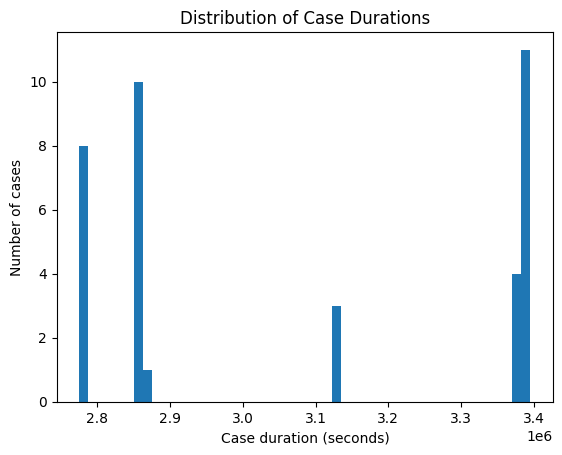

In [16]:
# Plot case duration histogram
import matplotlib.pyplot as plt

plt.hist(case_times['duration_seconds'], bins=50)
plt.xlabel("Case duration (seconds)")
plt.ylabel("Number of cases")
plt.title("Distribution of Case Durations")
plt.show()

## 10. Variants: identifying execution paths

A variant is a unique sequence of activities executed by a case.
Variants are essential for understanding process complexity and deviations.

In [14]:
# Build activity sequences per case
variants = (
    log_df_sorted
    .groupby('case:concept:name')['concept:name']
    .apply(tuple)
)

variants.head()

case:concept:name
0       (Enter store, Pickup Item, Pickup Item, Pickup...
1       (Enter store, Pickup Item, Pickup Item, Pickup...
10      (Enter store, Pickup Item, Pickup Item, Pickup...
100     (Enter store, Pickup Item, Pickup Item, Pickup...
1000    (Enter store, Pickup Item, Pickup Item, Pickup...
Name: concept:name, dtype: object

In [15]:
# Count variant frequencies
variant_counts = variants.value_counts().reset_index()
variant_counts.columns = ['variant', 'frequency']

variant_counts.head(10)


,variant,frequency
0,"(Enter store, Pickup Item, Pickup Item, Pickup...",15
1,"(Enter store, Pickup Item, Pickup Item, Pickup...",15
2,"(Enter store, Pickup Item, Pickup Item, Pickup...",14
3,"(Enter store, Pickup Item, Pickup Item, Pickup...",13
4,"(Enter store, Pickup Item, Pickup Item, Pickup...",12
5,"(Enter store, Pickup Item, Pickup Item, Pickup...",11
6,"(Enter store, Pickup Item, Pickup Item, Pickup...",11
7,"(Enter store, Pickup Item, Pickup Item, Pickup...",10
8,"(Enter store, Pickup Item, Pickup Item, Pickup...",10
9,"(Enter store, Pickup Item, Pickup Item, Pickup...",10


## 11. Activity frequency analysis

Activity frequencies provide a first structural view of the process.

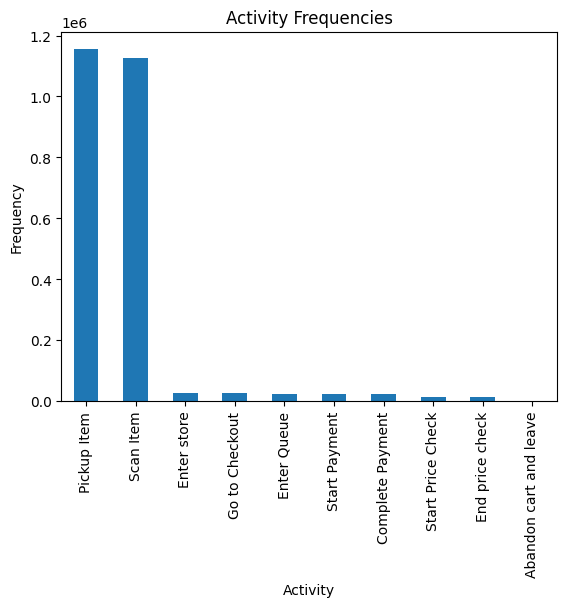

In [17]:
# Bar chart of activity frequencies
import matplotlib.pyplot as plt

activity_counts = log_df['concept:name'].value_counts()

activity_counts.plot(kind='bar')
plt.xlabel("Activity")
plt.ylabel("Frequency")
plt.title("Activity Frequencies")
plt.show()


## 12. Temporal analysis: arrivals over time

Event logs often exhibit strong temporal patterns:

- business hours
- daily/weekly seasonality
- batching effects

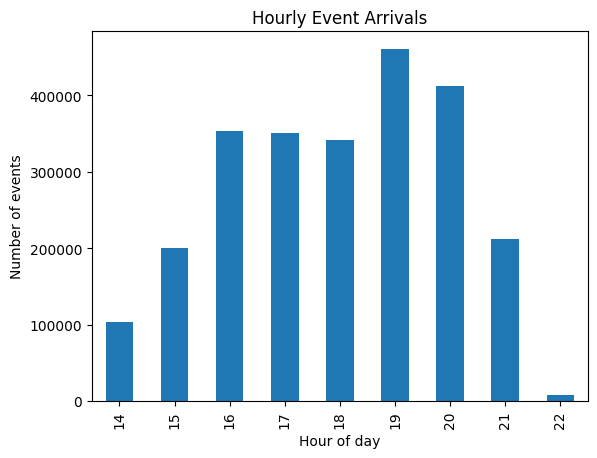

In [18]:
# Hourly arrivals
log_df['hour'] = log_df['time:timestamp'].dt.hour

hourly_arrivals = log_df.groupby('hour').size()

hourly_arrivals.plot(kind='bar')
plt.xlabel("Hour of day")
plt.ylabel("Number of events")
plt.title("Hourly Event Arrivals")
plt.show()

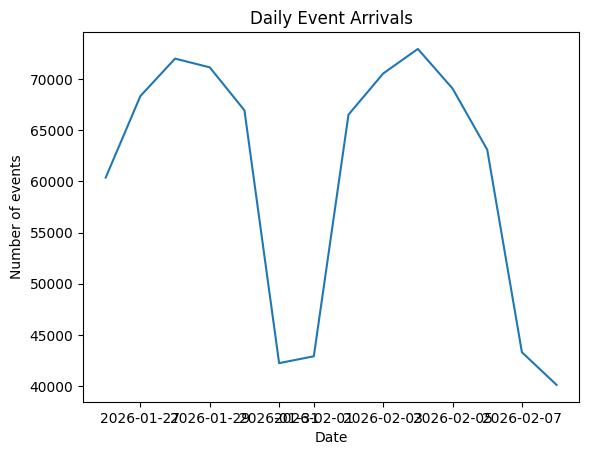

In [71]:
# Daily arrivals
log_df['date'] = log_df['time:timestamp'].dt.date

daily_arrivals = log_df.groupby('date').size()

daily_arrivals.plot()
plt.xlabel("Date")
plt.ylabel("Number of events")
plt.title("Daily Event Arrivals")
plt.show()


# EDA

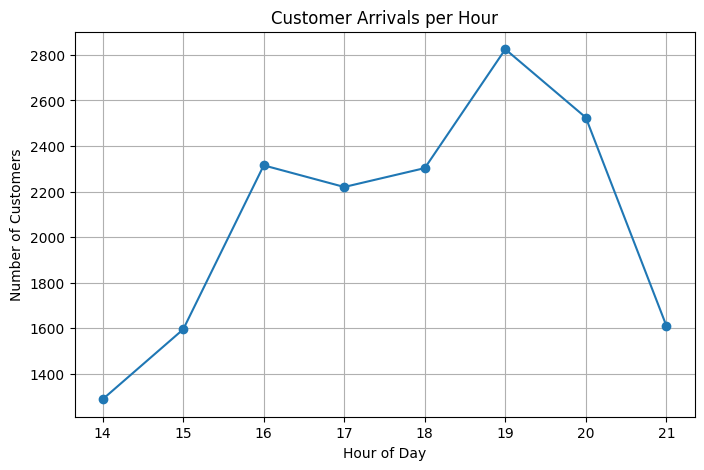

In [40]:
import matplotlib.pyplot as plt

# Filter only customer arrival events
arrival_events = log_df[
    log_df['concept:name'] == 'Enter store'
].copy()

# Extract hour from timestamp
arrival_events['hour'] = (
    arrival_events['time:timestamp'].dt.hour
)

# Count unique customers entering per hour
arrivals_by_hour = (
    arrival_events
    .groupby('hour')['case:concept:name']
    .nunique()
)

# Plot line graph
plt.figure(figsize=(8,5))

plt.plot(
    arrivals_by_hour.index,
    arrivals_by_hour.values,
    marker='o'
)

plt.title("Customer Arrivals per Hour")

plt.xlabel("Hour of Day")
plt.ylabel("Number of Customers")

plt.xticks(arrivals_by_hour.index)

plt.grid(True)

plt.show()

In [23]:
# Create an abandonment flag
log_df['abandoned'] = (
    log_df['concept:name'] == 'Abandon cart and leave'
)

In [24]:
log_df['abandoned'].value_counts()

abandoned
False    2440440
True         630
Name: count, dtype: int64

In [25]:
abandoned_cases = log_df[
    log_df['concept:name'] == 'Abandon cart and leave'
]['case:concept:name'].nunique()

total_customers = log_df['case:concept:name'].nunique()

abandonment_rate = abandoned_cases / total_customers

print("Abandoned customers:", abandoned_cases)
print("Total customers:", total_customers)
print("Abandonment rate:", abandonment_rate)

Abandoned customers: 588
Total customers: 9557
Abandonment rate: 0.06152558334205294


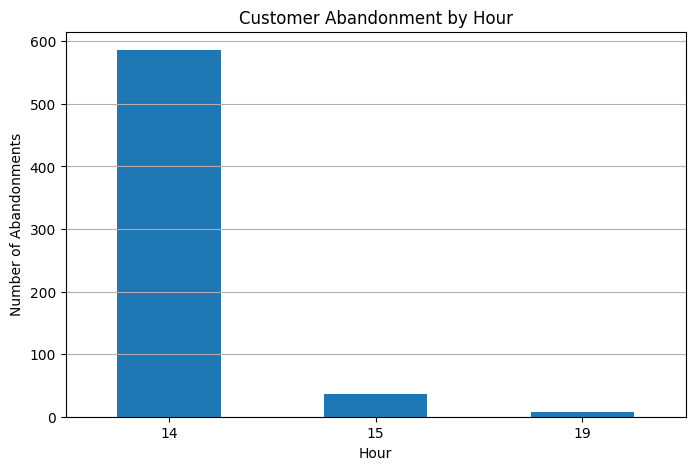

In [26]:
import matplotlib.pyplot as plt

abandonment_events = log_df[
    log_df['concept:name'] == 'Abandon cart and leave'
].copy()

abandonment_events['hour'] = abandonment_events['time:timestamp'].dt.hour

abandonment_by_hour = abandonment_events.groupby('hour').size()

abandonment_by_hour.plot(kind='bar', figsize=(8,5))

plt.title("Customer Abandonment by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Abandonments")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

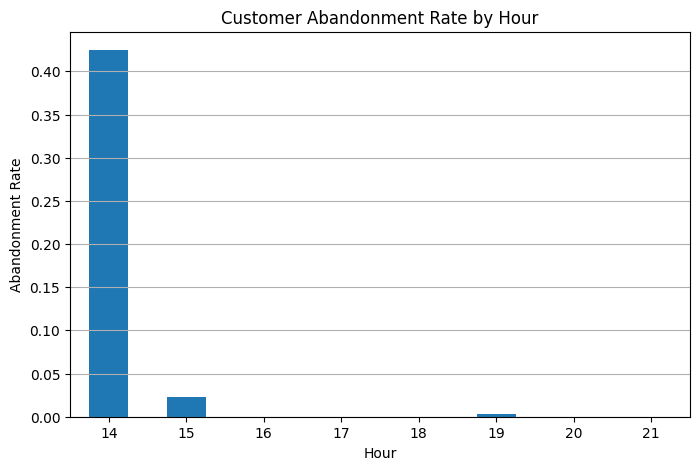

In [28]:
# total customers entering store by hour
enter_events = log_df[log_df['concept:name'] == 'Enter store'].copy()
enter_events['hour'] = enter_events['time:timestamp'].dt.hour

customers_by_hour = enter_events.groupby('hour')['case:concept:name'].nunique()

# abandoned customers by hour
abandonment_events = log_df[log_df['concept:name'] == 'Abandon cart and leave'].copy()
abandonment_events['hour'] = abandonment_events['time:timestamp'].dt.hour

abandonments_by_hour = abandonment_events.groupby('hour')['case:concept:name'].nunique()

# abandonment rate by hour
abandonment_rate_by_hour = (
    abandonments_by_hour / customers_by_hour
).fillna(0)

abandonment_rate_by_hour.plot(kind='bar', figsize=(8,5))

plt.title("Customer Abandonment Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Abandonment Rate")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [29]:
# customer waiting time
waiting_events = log_df[
    log_df['concept:name'].isin([
        'Enter Queue',
        'Start Payment'
    ])
].copy()

In [30]:
waiting_events = waiting_events.sort_values(
    ['case:concept:name', 'time:timestamp']
)

In [31]:
waiting_pairs = []

for customer_id, group in waiting_events.groupby('case:concept:name'):

    enter_queue = group[
        group['concept:name'] == 'Enter Queue'
    ]['time:timestamp'].reset_index(drop=True)

    start_payment = group[
        group['concept:name'] == 'Start Payment'
    ]['time:timestamp'].reset_index(drop=True)

    n = min(len(enter_queue), len(start_payment))

    for i in range(n):

        enter_time = enter_queue[i]
        payment_time = start_payment[i]

        waiting_minutes = (
            payment_time - enter_time
        ).total_seconds() / 60

        waiting_pairs.append({
            'customer_id': customer_id,
            'enter_queue_time': enter_time,
            'start_payment_time': payment_time,
            'waiting_minutes': waiting_minutes
        })

In [32]:
waiting_df = pd.DataFrame(waiting_pairs)

waiting_df.head()

,customer_id,enter_queue_time,start_payment_time,waiting_minutes
0,0,2026-01-26 14:03:27.627000+00:00,2026-01-26 14:06:23.209000+00:00,2.926367
1,0,2026-02-09 14:03:42.324000+00:00,2026-02-09 14:06:47.585000+00:00,3.087683
2,0,2026-02-20 14:03:26.511000+00:00,2026-02-20 14:06:23.327000+00:00,2.946933
3,1,2026-01-26 14:05:57.614000+00:00,2026-01-26 14:07:33.733000+00:00,1.601983
4,1,2026-02-09 14:07:23.361000+00:00,2026-02-09 14:11:11.126000+00:00,3.796083


In [33]:
waiting_df['waiting_minutes'].describe()

count    25325.000000
mean         3.935210
std          3.061747
min          0.076200
25%          2.379600
50%          3.333633
75%          4.914450
max         25.685200
Name: waiting_minutes, dtype: float64

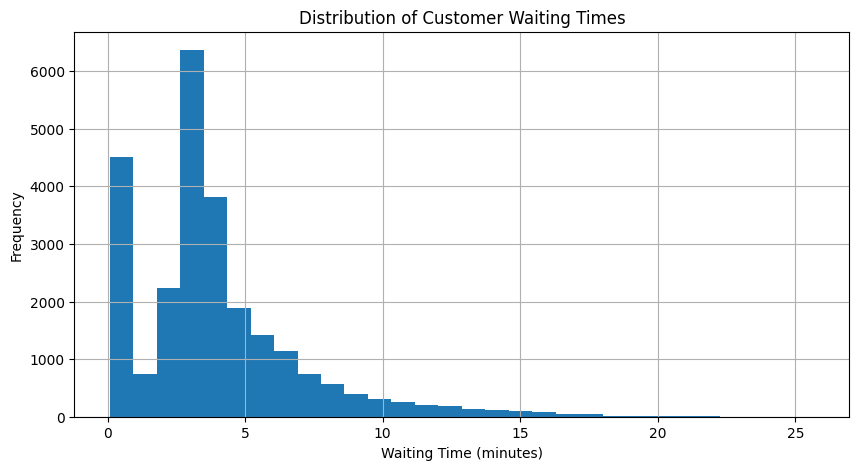

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    waiting_df['waiting_minutes'],
    bins=30
)

plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Frequency")

plt.title("Distribution of Customer Waiting Times")

plt.grid()

plt.show()

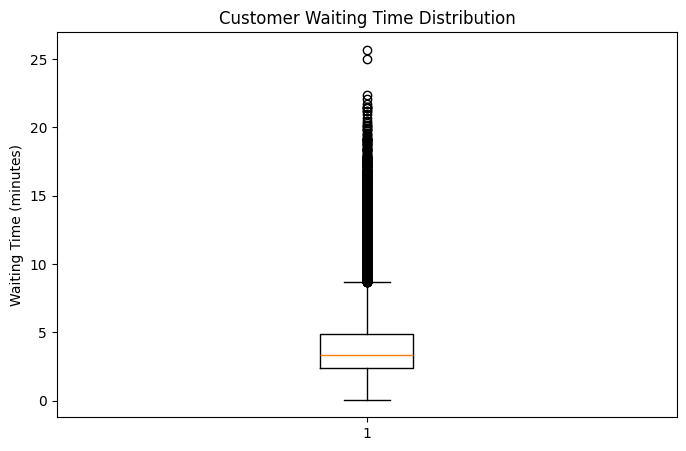

In [35]:
plt.figure(figsize=(8,5))

plt.boxplot(
    waiting_df['waiting_minutes']
)

plt.ylabel("Waiting Time (minutes)")

plt.title("Customer Waiting Time Distribution")

plt.show()

In [36]:
#### waiting time by hour
waiting_df['hour'] = (
    waiting_df['enter_queue_time']
    .dt.hour
)

In [37]:
waiting_by_hour = (
    waiting_df
    .groupby('hour')['waiting_minutes']
    .mean()
)

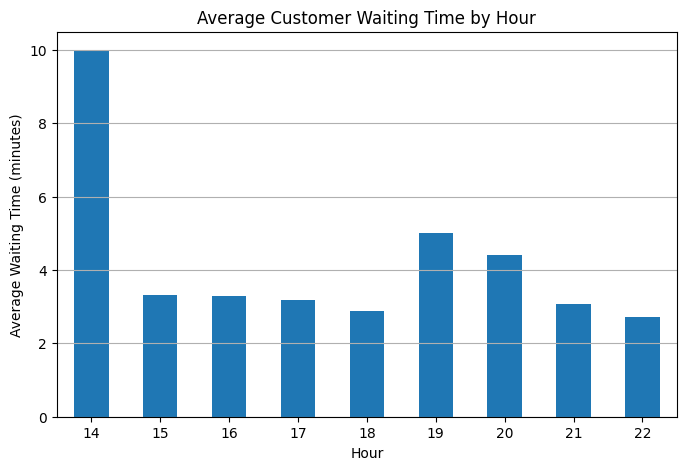

In [38]:
waiting_by_hour.plot(
    kind='bar',
    figsize=(8,5)
)

plt.xlabel("Hour")
plt.ylabel("Average Waiting Time (minutes)")

plt.title("Average Customer Waiting Time by Hour")

plt.xticks(rotation=0)

plt.grid(axis='y')

plt.show()

## 13. Dotted chart (process timeline visualization)

A dotted chart visualizes:

- x-axis → time
- y-axis → cases
- dots → events, colored by activity

This reveals concurrency, batching, and bottlenecks.

In [19]:
import seaborn as sns

In [20]:

start = pd.Timestamp("2026-01-26 15:00:00", tz="UTC")
end   = pd.Timestamp("2026-01-26 23:00:00", tz="UTC")

log_df_day = log_df[
    (log_df['time:timestamp'] >= start) &
    (log_df['time:timestamp'] < end)
]



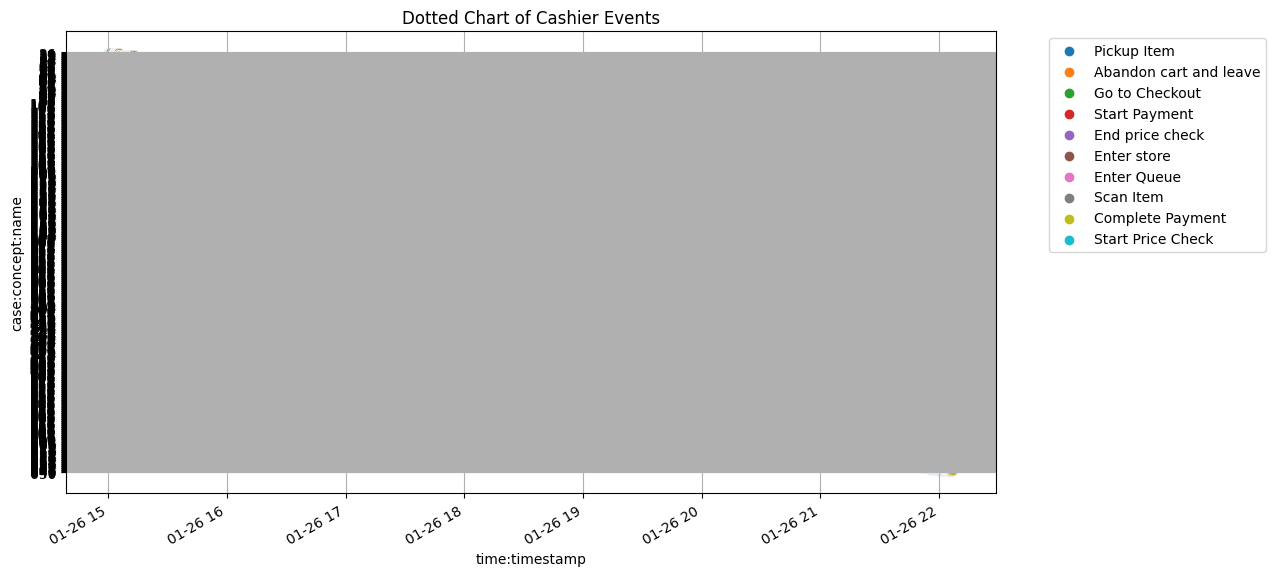

In [21]:
# dotted_chart = sns.scatterplot(log_df_day.sort_values(by="time:timestamp"), x='time:timestamp', y='case:concept:name', hue='concept:name', alpha=.7)
# sns.move_legend(dotted_chart, "upper left", bbox_to_anchor=(1, 1))
# plt.xticks(rotation=30, ha="right")
# plt.grid()
# dotted_chart;
plt.figure(figsize=(12,6))

dotted_chart = sns.scatterplot(
    data=log_df_day.sort_values(by="time:timestamp"),
    x='time:timestamp',
    y='case:concept:name',
    hue='concept:name',
    alpha=.7
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=30, ha="right")
plt.grid()

plt.title("Dotted Chart of Cashier Events")
plt.show()

In [27]:
# shift duration analysis
shift_events = log_df[
    log_df['concept:name'].isin(['Start Shift', 'End shift'])
].copy()

In [28]:
shift_events = shift_events.sort_values(
    ['case:concept:name', 'time:timestamp']
)

In [29]:
shift_pairs = []

for cashier_id, group in shift_events.groupby('case:concept:name'):

    starts = group[
        group['concept:name'] == 'Start Shift'
    ]['time:timestamp'].reset_index(drop=True)

    ends = group[
        group['concept:name'] == 'End shift'
    ]['time:timestamp'].reset_index(drop=True)

    # Pair corresponding starts and ends
    n = min(len(starts), len(ends))

    for i in range(n):

        start_time = starts[i]
        end_time = ends[i]

        duration_hours = (
            end_time - start_time
        ).total_seconds() / 3600

        shift_pairs.append({
            'cashier_id': cashier_id,
            'start_time': start_time,
            'end_time': end_time,
            'duration_hours': duration_hours
        })

In [30]:
shift_duration_df = pd.DataFrame(shift_pairs)

shift_duration_df.head()

,cashier_id,start_time,end_time,duration_hours
0,10,2026-01-26 16:00:00+00:00,2026-01-26 20:00:00+00:00,4.000000
1,10,2026-01-27 16:00:00+00:00,2026-01-27 20:01:49.936000+00:00,4.030538
2,10,2026-01-28 16:00:00+00:00,2026-01-28 20:17:49.951000+00:00,4.297209
3,10,2026-01-30 16:00:00+00:00,2026-01-30 20:00:00+00:00,4.000000
4,10,2026-01-31 16:00:00+00:00,2026-01-31 20:00:10.554000+00:00,4.002932


In [31]:
shift_duration_df['duration_hours'].describe()

count    732.000000
mean       3.310380
std        0.877631
min        2.000000
25%        2.130993
50%        4.000000
75%        4.045459
max        4.297209
Name: duration_hours, dtype: float64

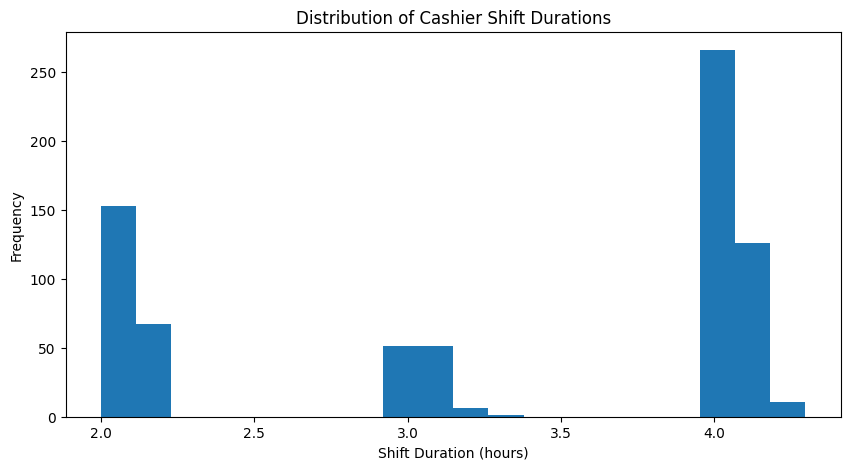

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    shift_duration_df['duration_hours'],
    bins=20
)

plt.xlabel("Shift Duration (hours)")
plt.ylabel("Frequency")
plt.title("Distribution of Cashier Shift Durations")

plt.show()

In [33]:
shift_duration_df.groupby('cashier_id')['duration_hours'].mean()

cashier_id
10    4.062377
13    4.101102
14    4.101102
15    4.101102
18    3.067297
19    3.064872
2     4.012188
21    3.089924
22    3.089924
24    2.022949
25    2.009422
26    2.010769
29    2.004903
3     3.064417
30    2.023303
35    2.074110
36    2.074110
39    4.155516
4     3.065065
40    4.084770
5     3.063818
54    3.051210
56    3.000000
58    3.032309
59    3.021740
6     3.063912
60    3.017578
62    4.082387
63    4.082387
67    4.085174
68    4.085174
69    3.085174
7     3.067084
71    4.007760
73    4.037188
8     4.020973
9     4.030944
Name: duration_hours, dtype: float64

In [ ]:
# active counters per hour, by choosing a particular day
counter_events = log_df[
    log_df['concept:name'].isin(['Open counter', 'Close counter'])
].copy()

In [ ]:
counter_events['counter_delta'] = counter_events[
    'concept:name'
].map({
    'Open counter': 1,
    'Close counter': -1
})

In [36]:
counter_events = counter_events.sort_values(
    'time:timestamp'
)

In [37]:
counter_events['active_counters'] = (
    counter_events['counter_delta']
    .cumsum()
)

In [39]:
selected_day = pd.to_datetime("2026-02-03").date()

In [40]:
daily_counter_events = counter_events[
    counter_events['time:timestamp'].dt.date == selected_day
].copy()

In [41]:
daily_counter_events['active_counters'] = (
    daily_counter_events['counter_delta']
    .cumsum()
)

In [42]:
daily_counter_events[
    [
        'time:timestamp',
        'concept:name',
        'counter_delta',
        'active_counters'
    ]
].head(20)

,time:timestamp,concept:name,counter_delta,active_counters
2677,2026-02-03 14:00:00+00:00,Open counter,1,1
2065,2026-02-03 15:00:00+00:00,Open counter,1,2
2461,2026-02-03 15:00:00+00:00,Open counter,1,3
1409,2026-02-03 15:00:00+00:00,Open counter,1,4
1025,2026-02-03 15:00:00+00:00,Open counter,1,5
1697,2026-02-03 15:00:00+00:00,Open counter,1,6
2721,2026-02-03 16:00:00+00:00,Open counter,1,7
25,2026-02-03 16:00:00+00:00,Open counter,1,8
2837,2026-02-03 16:00:00+00:00,Open counter,1,9
1893,2026-02-03 17:00:00+00:00,Open counter,1,10


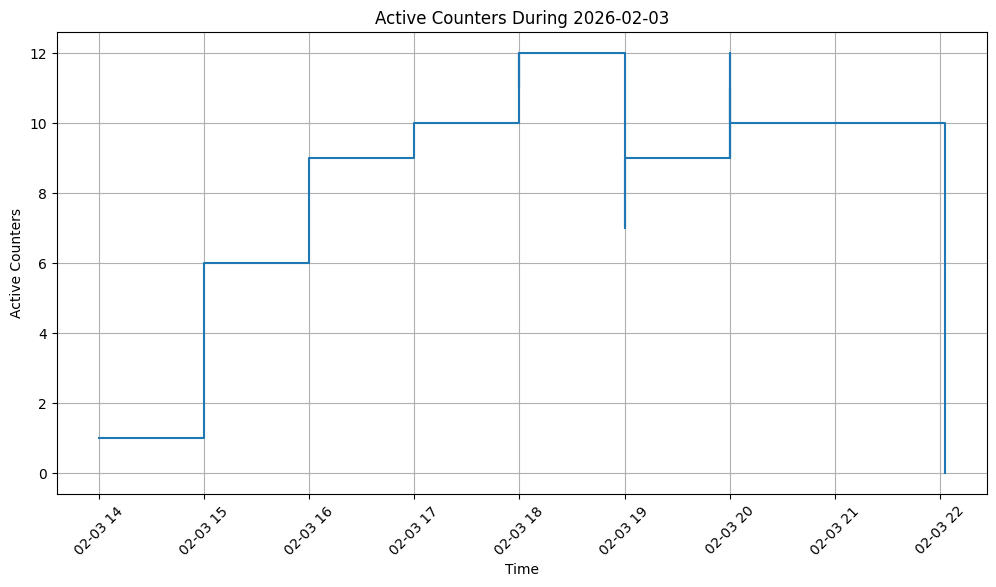

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.step(
    daily_counter_events['time:timestamp'],
    daily_counter_events['active_counters'],
    where='post'
)

plt.xlabel("Time")
plt.ylabel("Active Counters")
plt.title(f"Active Counters During {selected_day}")

plt.xticks(rotation=45)

plt.grid()

plt.show()

In [44]:
daily_counter_events['hour'] = (
    daily_counter_events['time:timestamp']
    .dt.hour
)

In [45]:
hourly_counters = (
    daily_counter_events
    .groupby('hour')['active_counters']
    .max()
)

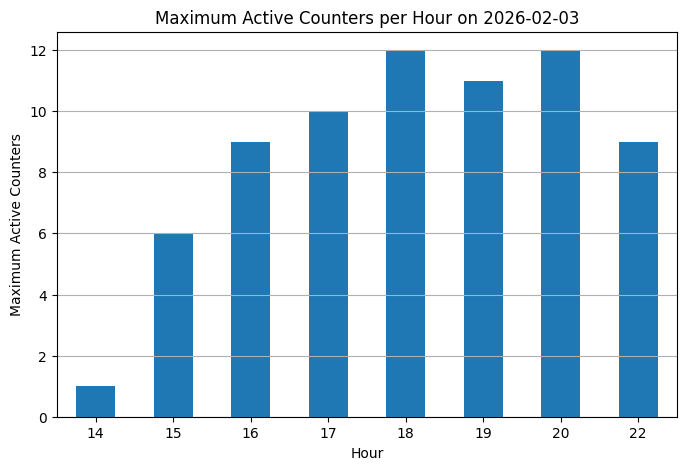

In [46]:
hourly_counters.plot(
    kind='bar',
    figsize=(8,5)
)

plt.xlabel("Hour")
plt.ylabel("Maximum Active Counters")

plt.title(
    f"Maximum Active Counters per Hour on {selected_day}"
)

plt.xticks(rotation=0)

plt.grid(axis='y')

plt.show()

## 14. Process discovery with pm4py

**Process discovery** automatically derives a process model from event data.
We start with the **Directly-Follows Graph (DFG)** and discover a **Petri net**.

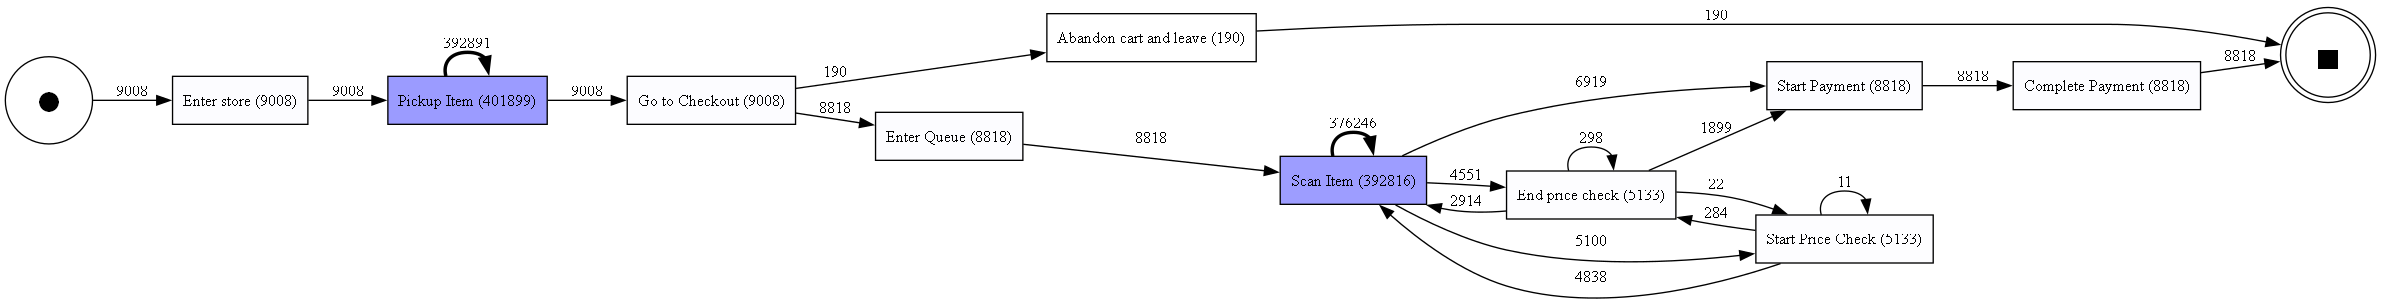

In [77]:
# Discover and visualize DFG
dfg, start_activities, end_activities = pm4py.discover_dfg(log)

pm4py.view_dfg(dfg, start_activities, end_activities)


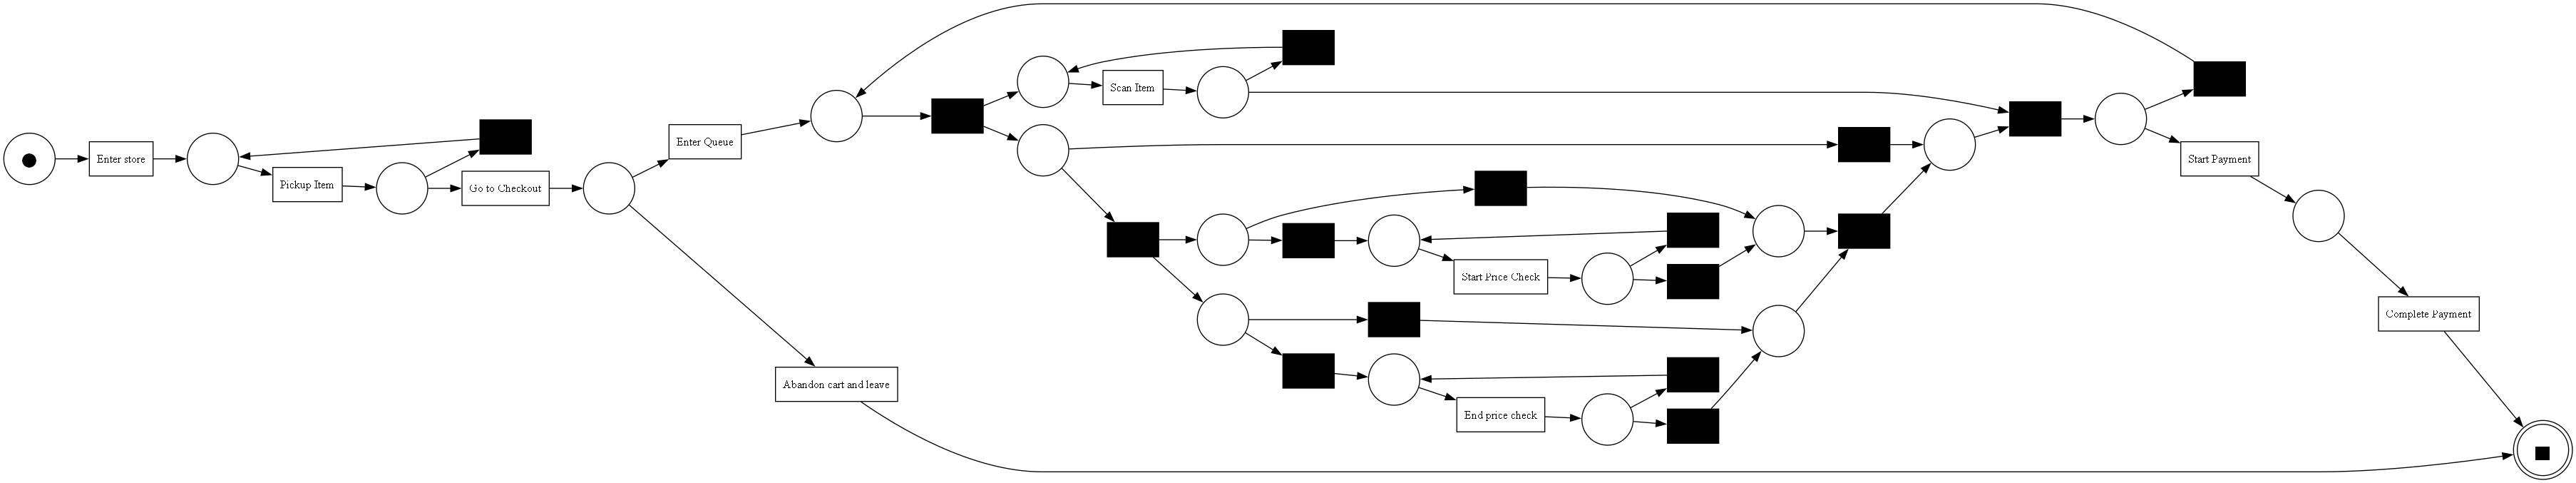

In [78]:
# Discover a Petri net (Inductive Miner)
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(log)

pm4py.view_petri_net(net, initial_marking, final_marking)


## Other things to consider when working with XES logs

- Missing or inconsistent timestamps
- Multiple events with identical timestamps
- Multiple lifecycle events (start / complete)
- Very large logs that do not fit in memory
- Assuming every case follows the same path

Always *inspect before modeling*.
